<a href="https://colab.research.google.com/github/shantiidp/Financial_Analyst_Agentic_RAG/blob/dev/Financial_Analyst_Agentic_RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Financial Analyst Agentic RAG
## Building a Production-Grade ReAct Agent with SQL Databases, PDF Policy Documents & Live Web Search

---

### Lab Overview

**Meridian Wealth Partners** manages ₹2,000 Cr in assets for 800 high-net-worth clients across India. Financial analysts spend 3-5 hours preparing for each quarterly client meeting — pulling portfolio data from internal databases, checking live market conditions, running performance calculations, searching investment policy PDFs, and browsing the web for sector news. In this lab, we build a **ReAct agent** that autonomously orchestrates **5 tools** to prepare client briefings in minutes.

**What makes this production-grade:**
- Client portfolios and market data live in a **SQLite database** (not Python dicts) — mirroring real enterprise data stores
- Investment policies are **real PDF documents** loaded, split, and embedded using LangChain's document processing pipeline
- The agent uses **Tavily web search** for real-time market intelligence
- The RAG retriever is a **tool the agent autonomously chooses when to use** — not a hardwired chain

| Tool | Data Source | What It Does |
|------|-----------|-------------|
| `portfolio_lookup` | SQLite DB (`clients` + `holdings` tables) | Fetch client holdings, allocation, total value |
| `market_data_search` | SQLite DB (`market_data` table) | Search ticker/sector performance data |
| `calculate_metrics` | Python computation | Compute returns, allocations, comparisons |
| `policy_retriever` | FAISS vector store (from 5 PDF documents) | RAG search over investment policy docs |
| `web_search` | Tavily API (live web) | Latest news, real-time market information |

### Learning Objectives

By the end of this lab, you will be able to:
1. Build a **production-grade RAG pipeline**: PDF loading → text splitting → embedding → vector store
2. Use **SQLite** as a structured data backend for agent tools (simulating enterprise databases)
3. Build a **ReAct agent** using LangGraph's `create_react_agent` with 5 integrated tools
4. Implement a **RAG retriever as an agent tool** — the agent decides when to search policy documents
5. Trace and analyze the agent's **Thought → Action → Observation** reasoning loops

---

### 🏗️ This is a Portfolio Project

This lab produces a production-grade deliverable: an AI agent backed by real databases and document retrieval, ready for your resume and GitHub portfolio.

---

## 1. Install Dependencies

In [1]:
# 📦 Packages this notebook needs — installed & upgraded to the latest versions (quiet, no version pins).
# On Colab this runs every session; locally it upgrades your venv.
!pip install -qU faiss-cpu graphviz langchain langchain-community langchain-core langchain-openai langchain-tavily langchain-text-splitters langgraph openai pypdf python-dotenv tavily-python

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 139.6/139.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 59.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.1/122.1 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.8/247.8 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 50.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.5/349.5 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 3.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently

In [6]:
!unzip "Lab 4.2 Policy Documents.zip" -d .

Archive:  Lab 4.2 Policy Documents.zip
   creating: ./Lab 4.2 Policy Documents/
   creating: ./Lab 4.2 Policy Documents/database/
  inflating: ./Lab 4.2 Policy Documents/database/meridian_wealth.db  
   creating: ./Lab 4.2 Policy Documents/docs/
  inflating: ./Lab 4.2 Policy Documents/docs/Asset_Allocation_Policy.pdf  
  inflating: ./Lab 4.2 Policy Documents/docs/Client_Suitability_Standards.pdf  
  inflating: ./Lab 4.2 Policy Documents/docs/Quarterly_Reporting_Standards.pdf  
  inflating: ./Lab 4.2 Policy Documents/docs/Rebalancing_Protocol.pdf  
  inflating: ./Lab 4.2 Policy Documents/docs/Risk_Management_Guidelines.pdf  


## 2. API Key Configuration

> **Setup:** Go to the 🔑 icon in Colab's left sidebar → Add `OPENAI_API_KEY` and `TAVILY_API_KEY` → Toggle "Notebook access" ON.
>
> **Tavily API Key:** Sign up free at [tavily.com](https://tavily.com) → Dashboard → Copy API key. Free tier includes 1,000 searches/month.

In [8]:
import os, json, sqlite3, textwrap, re

def load_keys(required):
    """Load API keys from Colab Secrets (on Colab) or a local .env file (elsewhere)."""
    try:
        from google.colab import userdata          # running on Google Colab
        for key_name in required:
            try:
                os.environ[key_name] = userdata.get(key_name)
            except Exception:
                pass                                 # not set in Colab Secrets
        source = "Colab Secrets"
    except ImportError:                              # running locally / non-Colab
        try:
            from dotenv import load_dotenv, find_dotenv
            load_dotenv(find_dotenv(usecwd=True))     # searches cwd upward for a .env
        except ImportError:
            pass
        source = ".env / environment"
    print(f"🔑 Key source: {source}")
    for key_name in required:
        print(f"   {key_name:<22} {'✅' if os.environ.get(key_name) else '❌ MISSING'}")

# TAVILY_API_KEY powers the live web-search tool (free tier at tavily.com).
load_keys(["OPENAI_API_KEY", "TAVILY_API_KEY"])

🔑 Key source: Colab Secrets
   OPENAI_API_KEY         ✅
   TAVILY_API_KEY         ✅


## 3. Initialize Clients & Imports

In [9]:
from openai import OpenAI
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.tools import tool
# from langgraph.prebuilt import create_react_agent  # langchain 0.3.3
from langchain.agents import create_agent  # as per langchain v1.01
from langchain_tavily import TavilySearch

client = OpenAI()
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")
chat_model = ChatOpenAI(model="gpt-5-mini")

print("All clients initialized ✅")
print(f"  Agent LLM: gpt-5-mini (via ChatOpenAI)")
print(f"  Embeddings: text-embedding-3-small")
print(f"  Web Search: Tavily API")

All clients initialized ✅
  Agent LLM: gpt-5-mini (via ChatOpenAI)
  Embeddings: text-embedding-3-small
  Web Search: Tavily API


## 4. Agent Architecture

```
                         ┌──────────────────────┐
                         │   User Query         │
                         │ "Prepare briefing    │
                         │  for Client CLT-001" │
                         └──────────┬───────────┘
                                    │
                                    ▼
                    ┌───────────────────────────────┐
                    │       ReAct Agent (LLM)       │
                    │   gpt-5-mini via LangGraph    │
                    │                               │
                    │  Loop: Thought → Action →     │
                    │        Observation → ...      │
                    └──────┬──┬──┬──┬──┬────────────┘
                           │  │  │  │  │
              ┌────────────┘  │  │  │  └────────────┐
              ▼               ▼  │  ▼               ▼
    ┌──────────────┐ ┌────────┐  │ ┌──────────┐ ┌──────────┐
    │ portfolio_   │ │market_ │  │ │ policy_  │ │  web_    │
    │ lookup       │ │data_   │  │ │retriever │ │ search   │
    │              │ │search  │  │ │ (RAG)    │ │(Tavily)  │
    │ Client DB    │ │Ticker  │  │ │ FAISS +  │ │ Live web │
    │ Holdings     │ │Data    │  │ │ Policies │ │ results  │
    └──────────────┘ └────────┘  │ └──────────┘ └──────────┘
                                 ▼
                        ┌──────────────┐
                        │ calculate_   │
                        │ metrics      │
                        │ Returns,     │
                        │ allocations  │
                        └──────────────┘
```

**Data architecture mirrors real enterprise systems:**
- **Structured data** (portfolios, market prices) → SQL database (SQLite)
- **Unstructured data** (policy documents) → PDF files → chunked → embedded → FAISS vector store
- **Real-time data** (news, market updates) → Tavily web search API

5-tool agent architecture

**Figure — 5-tool agent architecture.** One ReAct agent (`create_agent` on the LangGraph runtime) autonomously calls one or more of five tools, four of which are backed by three independent data systems (SQLite, FAISS, Tavily).

## About the ReAct Agent:

The ReAct agent we are building is best described as a **LangChain agent that runs on LangGraph**: we'll create it through LangChain’s high-level `create_agent` API, but under the hood that API builds a **graph-based runtime using LangGraph**, where the execution loop is modeled as nodes and edges such as the model node, tools node, and stop/final-output path.

In other words, **LangChain is the developer-facing abstraction**, while **LangGraph is the orchestration/runtime layer** actually managing the ReAct loop, tool execution, middleware, streaming, persistence, and related agent control flow.

You use LangChain because it gives you the simpler, faster, more ergonomic entry point for common agent patterns, provider integrations, tools, and middleware, whereas you drop down to LangGraph only when you need lower-level control over custom orchestration, state transitions, durable execution, or nonstandard agent workflows. ([LangChain Docs][1])

[1]: https://docs.langchain.com/oss/python/langchain/agents?utm_source=chatgpt.com "Agents - Docs by LangChain"


In [10]:
# Data is PRE-PROVIDED — the 5 investment-policy PDFs + meridian_wealth.db. No dataset/DB-creation step.
# On Colab, upload the data folders next to this notebook (docs/ + database/, or the delivery folder).
import os
def resolve(relative_path):
    """Find a pre-provided data file/folder across the likely locations."""
    for base_folder in ("", "Lab 4.2 Policy Documents/", "../", "../Lab 4.2 Policy Documents/"):
        candidate_path = base_folder + relative_path
        if os.path.exists(candidate_path):
            return candidate_path
    raise FileNotFoundError(f"Could not find '{relative_path}'. On Colab, upload the data folder next to this notebook.")

database_path, docs_dir = resolve("database/meridian_wealth.db"), resolve("docs")
print("✅ Data found:")
print("   DB  :", database_path)
print("   docs:", docs_dir, "→", sorted(file_name for file_name in os.listdir(docs_dir) if file_name.endswith(".pdf")))

✅ Data found:
   DB  : Lab 4.2 Policy Documents/database/meridian_wealth.db
   docs: Lab 4.2 Policy Documents/docs → ['Asset_Allocation_Policy.pdf', 'Client_Suitability_Standards.pdf', 'Quarterly_Reporting_Standards.pdf', 'Rebalancing_Protocol.pdf', 'Risk_Management_Guidelines.pdf']


## 5. Connect to the SQLite Database

In [12]:
DB_PATH = resolve("database/meridian_wealth.db")

# Verify database exists and has data
assert os.path.exists(DB_PATH), f"❌ Database not found at {DB_PATH}. Ensure the data folder is present."

conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

print(f"✅ Connected to database: {DB_PATH}")
print(f"   File size: {os.path.getsize(DB_PATH) / 1024:.1f} KB\n")

for table in ["clients", "holdings", "market_data"]:
    count = cursor.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"   📋 {table}: {count} rows")

# Preview clients
print("\n👤 Clients:")
for client_row in cursor.execute("SELECT client_id, name, risk_profile, aum_inr FROM clients"):
    print(f"   {client_row[0]}: {client_row[1]} | {client_row[2]} | AUM: ₹{client_row[3]:,.0f}")

conn.close()

✅ Connected to database: Lab 4.2 Policy Documents/database/meridian_wealth.db
   File size: 28.0 KB

   📋 clients: 5 rows
   📋 holdings: 23 rows
   📋 market_data: 10 rows

👤 Clients:
   CLT-001: Rajesh Mehta | Moderate-Aggressive | AUM: ₹12,500,000
   CLT-002: Priya Kapoor | Conservative | AUM: ₹8,500,000
   CLT-003: Amit Choudhury | Aggressive | AUM: ₹25,000,000
   CLT-004: Sunita Reddy | Moderate | AUM: ₹5,000,000
   CLT-005: Karan Malhotra | Aggressive | AUM: ₹18,000,000


## 6. Load Policy PDFs → Split → Embed → FAISS Vector Store

This is the production RAG pipeline. We load 5 real PDF policy documents through LangChain's document processing chain:

1. **`PyPDFLoader`** — extracts text from each PDF page (preserving page metadata)
2. **`RecursiveCharacterTextSplitter`** — breaks text into overlapping chunks (500 chars, 100 overlap)
3. **`OpenAIEmbeddings`** — converts each chunk to a 1536-dimensional vector
4. **`FAISS`** — indexes vectors for fast similarity search at query time

This is exactly how enterprise RAG systems work with corporate document repositories.

policy_retriever RAG pipeline

**Figure — The `policy_retriever` RAG pipeline.** Five policy PDFs are chunked, embedded, and indexed once; every `policy_retriever` call then searches that FAISS index for the top-4 most relevant excerpts.

In [11]:
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.vectorstores import FAISS

POLICY_DIR = resolve("docs")
assert os.path.exists(POLICY_DIR), f"❌ Policy documents not found at {POLICY_DIR}/. Ensure the data folder is present."

# Step 1: Load all PDFs using LangChain's PyPDFLoader
all_pages = []
pdf_files = sorted([file_name for file_name in os.listdir(POLICY_DIR) if file_name.endswith(".pdf")])

print(f"📄 Loading {len(pdf_files)} policy PDFs...\n")
for pdf_file in pdf_files:
    loader = PyPDFLoader(os.path.join(POLICY_DIR, pdf_file))
    pages = loader.load()
    all_pages.extend(pages)
    print(f"   {pdf_file}: {len(pages)} pages loaded")

print(f"\n✅ Total pages extracted: {len(all_pages)}")

📄 Loading 5 policy PDFs...

   Asset_Allocation_Policy.pdf: 20 pages loaded
   Client_Suitability_Standards.pdf: 71 pages loaded
   Quarterly_Reporting_Standards.pdf: 33 pages loaded
   Rebalancing_Protocol.pdf: 20 pages loaded
   Risk_Management_Guidelines.pdf: 30 pages loaded

✅ Total pages extracted: 174


In [13]:
type(all_pages[0])

langchain_core.documents.base.Document

In [14]:
# Step 2: Split into chunks
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,         # ~125 words per chunk — good for policy docs
    chunk_overlap=100,       # 100 char overlap prevents losing context at chunk boundaries
    length_function=len,
    separators=["\n\n", "\n", ". ", " ", ""]  # split on paragraphs first, then sentences
)

chunks = text_splitter.split_documents(all_pages)
print(f"✅ Split into {len(chunks)} chunks (chunk_size=500, overlap=100)")


✅ Split into 1224 chunks (chunk_size=500, overlap=100)


In [15]:
# Preview a few chunks
print(f"\n📋 Sample Chunks:")
for chunk_index in [0, len(chunks)//3, 2*len(chunks)//3]:
    chunk = chunks[chunk_index]
    source_name = os.path.basename(chunk.metadata.get("source", "?"))
    page_number = chunk.metadata.get("page", "?")
    print(f"\n  Chunk [{chunk_index}] from {source_name} (page {page_number}):")
    print(f"  \"{chunk.page_content[:120]}...\"")


📋 Sample Chunks:

  Chunk [0] from Asset_Allocation_Policy.pdf (page 0):
  "MERIDIAN WEALTH PARTNERS
 ASSET ALLOCATION POLICY
 Investment Advisory Firm | SEBI Registration: INA000015429
 Effective..."

  Chunk [408] from Client_Suitability_Standards.pdf (page 41):
  "client advisory relationships must carefully review and completely understand the requirements specified
herein and ensu..."

  Chunk [816] from Quarterly_Reporting_Standards.pdf (page 21):
  "the source of truth for the number of shares held and the cash balance. Any discrepancies between the
Firm's records and..."


In [16]:
# Step 3 & 4: Embed and build FAISS vector store
print(f"\n⏳ Embedding {len(chunks)} chunks with text-embedding-3-small...")
policy_vectorstore = FAISS.from_documents(chunks, embedding_model)
policy_retriever_chain = policy_vectorstore.as_retriever(search_kwargs={"k": 4})

print(f"\n✅ FAISS vector store built:")
print(f"   Vectors: {policy_vectorstore.index.ntotal}")
print(f"   Embedding dimensions: 1,536")
print(f"   Retriever: top-4 similarity search")


⏳ Embedding 1224 chunks with text-embedding-3-small...

✅ FAISS vector store built:
   Vectors: 1224
   Embedding dimensions: 1,536
   Retriever: top-4 similarity search


## 7. Test RAG Retrieval on Policy Documents

Before wiring the retriever into the agent, let's verify it returns relevant policy excerpts for sample queries.

In [17]:
test_queries = [
    "What is the maximum single stock concentration allowed?",
    "What are the drawdown limits for an Aggressive profile?",
    "How should we rebalance when tax year end is approaching?"
]

for query in test_queries:
    documents = policy_retriever_chain.invoke(query)
    print(f"🔍 Query: \"{query}\"")
    for rank, document in enumerate(documents[:2], 1):  # show top-2
        source_name = os.path.basename(document.metadata.get("source", "?"))
        page_number = document.metadata.get("page", "?")
        print(f"   [{rank}] {source_name} (p{page_number}): {document.page_content[:120]}...")
    print()

🔍 Query: "What is the maximum single stock concentration allowed?"
   [1] Risk_Management_Guidelines.pdf (p18): maximum 3% of portfolio in any single corporate bond issuer, 5% in any single PSU bond issuer, and
unlimited in Governme...
   [2] Risk_Management_Guidelines.pdf (p18): 9. CONCENTRATION RISK FRAMEWORK
9.1 Single-Issuer and Sector Concentration Limits
Excessive concentration in a single se...

🔍 Query: "What are the drawdown limits for an Aggressive profile?"
   [1] Risk_Management_Guidelines.pdf (p6): frameworks for aggressive and moderate-aggressive investment profiles.
Maximum Drawdown
Maximum Drawdown measures the la...
   [2] Risk_Management_Guidelines.pdf (p21): 11. PORTFOLIO RISK LIMITS & THRESHOLDS
11.1 Risk Limit Framework by Portfolio Profile
The Firm establishes portfolio ris...

🔍 Query: "How should we rebalance when tax year end is approaching?"
   [1] Rebalancing_Protocol.pdf (p9): periodic audit review.
8. Tax-Efficient Rebalancing Strategies...
   [2] Rebalanci

## 8. Database Query Helpers

These functions wrap SQL queries that our agent tools will use. In production, these would be API endpoints or stored procedures.

In [19]:
def query_db(sql_query, params=()):
    """Execute a SQL query against the Meridian Wealth database and return rows as dicts."""
    conn = sqlite3.connect(DB_PATH)
    conn.row_factory = sqlite3.Row
    cursor = conn.cursor()
    cursor.execute(sql_query, params)
    rows = [dict(table_row) for table_row in cursor.fetchall()]
    conn.close()
    return rows


def get_client_portfolio(client_id):
    """Get full portfolio for a client with enriched market data."""
    client = query_db("SELECT * FROM clients WHERE client_id = ?", (client_id,))
    if not client:
        return None
    holdings = query_db("""
        SELECT h.ticker, h.company_name, h.shares, h.avg_cost_basis, h.current_price,
               h.sector, h.purchase_date,
               m.ytd_return_pct, m.pe_ratio, m.analyst_rating, m.high_52w, m.low_52w
        FROM holdings h
        LEFT JOIN market_data m ON h.ticker = m.ticker
        WHERE h.client_id = ?
        ORDER BY (h.shares * h.current_price) DESC
    """, (client_id,))
    return {"client": client[0], "holdings": holdings}


def search_market_data(query):
    """Search market data by ticker, sector, or company name."""
    normalized_query = query.upper().strip()
    results = query_db("SELECT * FROM market_data WHERE ticker = ?", (normalized_query,))
    if not results:
        results = query_db(
            "SELECT * FROM market_data WHERE UPPER(sector) LIKE ? OR UPPER(company_name) LIKE ? OR ticker LIKE ?",
            (f"%{normalized_query}%", f"%{normalized_query}%", f"%{normalized_query}%")
        )
    return results

portfolio = get_client_portfolio("CLT-001")
print(f"✅ DB helpers ready. Test: {portfolio['client']['name']} has {len(portfolio['holdings'])} holdings")

✅ DB helpers ready. Test: Rajesh Mehta has 5 holdings


## 9. Define Agent Tools

Five tools, each backed by real data infrastructure. The `@tool` docstring is what the LLM reads to decide *when* to use each tool.

| Tool | Backend | Returns |
|------|---------|---------|
| `portfolio_lookup` | SQLite (JOIN clients + holdings + market_data) | Client profile + enriched holdings |
| `market_data_search` | SQLite (market_data table) | Ticker/sector performance, ratings |
| `calculate_metrics` | Python computation | Financial calculations |
| `policy_retriever` | FAISS (from 5 PDF policy documents) | Relevant policy excerpts with page citations |
| `web_search` | Tavily API (live) | Web search results |

Tool selection

**Figure — Tool selection.** Each tool's `@tool` docstring is the signal the LLM reads to match what a reasoning step needs to exactly one of the five tools.

In [20]:
@tool
def portfolio_lookup(client_id: str) -> str:
    """Look up a client's portfolio from the database: holdings, allocation, total value, and risk profile.
    Use this when you need to know what a specific client owns or their investment profile.
    Input: client ID like 'CLT-001', 'CLT-002', etc."""

    portfolio = get_client_portfolio(client_id.upper())
    if not portfolio:
        available = [record["client_id"] for record in query_db("SELECT client_id FROM clients")]
        return f"Client {client_id} not found. Available: {', '.join(available)}"

    client_record = portfolio["client"]
    holdings = portfolio["holdings"]

    total_current = sum(holding["shares"] * holding["current_price"] for holding in holdings)
    total_cost = sum(holding["shares"] * holding["avg_cost_basis"] for holding in holdings)
    overall_return = ((total_current - total_cost) / total_cost) * 100

    sector_values = {}
    for holding in holdings:
        holding_value = holding["shares"] * holding["current_price"]
        sector_values[holding["sector"]] = sector_values.get(holding["sector"], 0) + holding_value
    sector_percentages = {sector: round((sector_value / total_current) * 100, 1)
                          for sector, sector_value in sector_values.items()}

    holdings_detail = []
    for holding in holdings:
        current_value = holding["shares"] * holding["current_price"]
        gain = ((holding["current_price"] - holding["avg_cost_basis"]) / holding["avg_cost_basis"]) * 100
        portfolio_weight = (current_value / total_current) * 100
        holdings_detail.append({
            "ticker": holding["ticker"], "company": holding["company_name"],
            "shares": holding["shares"], "avg_cost": holding["avg_cost_basis"],
            "current_price": holding["current_price"], "current_value": current_value,
            "unrealized_gain_pct": round(gain, 1), "portfolio_weight_pct": round(portfolio_weight, 1),
            "sector": holding["sector"], "ytd_return": holding["ytd_return_pct"],
            "analyst_rating": holding["analyst_rating"], "purchase_date": holding["purchase_date"]
        })

    result = {
        "client_id": client_record["client_id"], "name": client_record["name"],
        "relationship_manager": client_record["relationship_mgr"], "risk_profile": client_record["risk_profile"],
        "investment_horizon": client_record["investment_horizon"], "aum_inr": client_record["aum_inr"],
        "last_review": client_record["last_review"],
        "total_portfolio_value": round(total_current),
        "total_cost_basis": round(total_cost),
        "overall_return_pct": round(overall_return, 1),
        "sector_allocation": sector_percentages,
        "holdings": holdings_detail
    }
    return json.dumps(result, indent=2, ensure_ascii=False)


@tool
def market_data_search(query: str) -> str:
    """Search the market database for stock tickers or sectors. Returns current price, YTD returns,
    PE ratio, analyst ratings, 52-week range, and market cap. Use this when you need market
    performance data for specific stocks or want to compare sector performance.
    Input: a stock ticker (e.g. 'RELIANCE'), sector name (e.g. 'IT', 'Banking'), or company name."""

    results = search_market_data(query)
    if not results:
        all_tickers = [record["ticker"] for record in query_db("SELECT ticker FROM market_data")]
        return f"No data found for '{query}'. Available: {', '.join(all_tickers)}"

    formatted = [{
        "ticker": record["ticker"], "company": record["company_name"], "sector": record["sector"],
        "price": record["current_price"], "ytd_return": record["ytd_return_pct"],
        "pe_ratio": record["pe_ratio"], "analyst_rating": record["analyst_rating"],
        "52w_range": f"{record['low_52w']} - {record['high_52w']}",
        "market_cap_cr": record["market_cap_cr"]
    } for record in results]
    return json.dumps(formatted, indent=2, ensure_ascii=False)


@tool
def calculate_metrics(expression: str) -> str:
    """Perform financial calculations: returns, percentages, allocations, comparisons.
    Input: describe the calculation, e.g. 'return on 596000 vs cost 430000'
    or 'percentage of 350000 out of 2530000' or 'compare 18.5 vs 12.3'."""
    try:
        numbers = [float(token.replace(',', '')) for token in re.findall(r'[\d,]+\.?\d*', expression)]

        if "return" in expression.lower() or "gain" in expression.lower():
            if len(numbers) >= 2:
                current, cost = numbers[0], numbers[1]
                return_pct = ((current - cost) / cost) * 100
                return f"Return: (₹{current:,.0f} - ₹{cost:,.0f}) / ₹{cost:,.0f} = {return_pct:+.2f}%"

        if "percentage" in expression.lower() or "allocation" in expression.lower() or "weight" in expression.lower():
            if len(numbers) >= 2:
                part, whole = numbers[0], numbers[1]
                return f"Percentage: ₹{part:,.0f} / ₹{whole:,.0f} = {(part/whole)*100:.2f}%"

        if "compare" in expression.lower() and len(numbers) >= 2:
            first_value, second_value = numbers[0], numbers[1]
            return f"Comparison: {first_value:,.2f} vs {second_value:,.2f} | Diff: {first_value-second_value:+,.2f} ({((first_value-second_value)/second_value)*100:+.2f}%)"

        if len(numbers) == 2:
            first_value, second_value = numbers
            return f"Values: {first_value:,.2f} and {second_value:,.2f} | Sum: {first_value+second_value:,.2f} | Diff: {first_value-second_value:+,.2f} | Ratio: {first_value/second_value:.4f}"

        return f"Provide two numbers with operation type (return, percentage, compare). Got: '{expression}'"
    except Exception as error:
        return f"Calculation error: {str(error)}"


@tool
def policy_retriever(query: str) -> str:
    """Search Meridian Wealth Partners' investment policy PDF documents using RAG (vector similarity search).
    Use this when you need to check investment guidelines, allocation rules, rebalancing triggers,
    risk limits, concentration limits, suitability standards, or reporting requirements.
    Returns relevant excerpts with source document name and page number.
    Input: a natural language query about investment policies."""

    documents = policy_retriever_chain.invoke(query)
    results = []
    for rank, document in enumerate(documents, 1):
        source_name = os.path.basename(document.metadata.get("source", "unknown"))
        page_number = document.metadata.get("page", "?")
        results.append(f"[Policy Doc {rank}: {source_name} | Page {page_number}]\n{document.page_content}")
    return "\n\n---\n\n".join(results)

In [21]:
# Tavily web search — live market news
web_search = TavilySearch(max_results=3, topic="news")

# All tools
tools = [portfolio_lookup, market_data_search, calculate_metrics, policy_retriever, web_search]

print(f"✅ {len(tools)} tools defined:")
for agent_tool in tools:
    print(f"   🔧 {agent_tool.name}: {agent_tool.description[:80]}...")

✅ 5 tools defined:
   🔧 portfolio_lookup: Look up a client's portfolio from the database: holdings, allocation, total valu...
   🔧 market_data_search: Search the market database for stock tickers or sectors. Returns current price, ...
   🔧 calculate_metrics: Perform financial calculations: returns, percentages, allocations, comparisons.
...
   🔧 policy_retriever: Search Meridian Wealth Partners' investment policy PDF documents using RAG (vect...
   🔧 tavily_search: A search engine optimized for comprehensive, accurate, and trusted results. Usef...


## 10. Create the ReAct Agent

The system prompt gives the agent its persona, guidelines, and awareness of available data sources.

In [22]:
SYSTEM_PROMPT = """You are a senior financial analyst at Meridian Wealth Partners, a SEBI-registered wealth
management firm managing Rs 2,000 Crore in assets across 800 high-net-worth Indian clients.

Your job is to prepare comprehensive client briefings and answer investment queries using your tools.

AVAILABLE DATA SOURCES:
1. portfolio_lookup — queries the SQL database for client holdings, allocation, and risk profile
2. market_data_search — queries the SQL database for stock/sector data (price, YTD, PE, analyst ratings)
3. calculate_metrics — computes financial metrics (returns, allocation percentages, comparisons)
4. policy_retriever — RAG search over the firm's 5 investment policy PDFs (asset allocation, risk management,
   suitability standards, rebalancing protocol, reporting standards)
5. tavily_search — searches the web for latest market news, RBI updates, sector analysis

GUIDELINES:
- Always check the client's risk profile before making recommendations
- When checking policy compliance, ALWAYS use the policy_retriever tool — never guess the rules
- Cite specific policy document names and page numbers when referencing guidelines
- Do not provide compliance conclusions without first using policy_retriever.
- Do not provide market-news claims without using tavily_search.
- If required data is missing, say so explicitly instead of inferring.
- Use Indian Rupee (₹) for all amounts. Use lakhs and crores for large values.
- Include specific numbers: exact returns, allocation percentages, policy thresholds
- For briefings, structure as: Portfolio Summary → Market Context → Policy Compliance → Recommendations
"""

# agent = create_react_agent(llm, tools, prompt=SYSTEM_PROMPT)

agent = create_agent(
    model="openai:gpt-5-mini",
    tools=tools,
    system_prompt=SYSTEM_PROMPT,
)

print("✅ ReAct agent created")
print(f"   LLM: gpt-5-mini (ChatOpenAI)")
print(f"   Tools: {[agent_tool.name for agent_tool in tools]}")
print(f"   Data: SQLite DB + FAISS (from 5 PDFs) + Tavily web search")

✅ ReAct agent created
   LLM: gpt-5-mini (ChatOpenAI)
   Tools: ['portfolio_lookup', 'market_data_search', 'calculate_metrics', 'policy_retriever', 'tavily_search']
   Data: SQLite DB + FAISS (from 5 PDFs) + Tavily web search


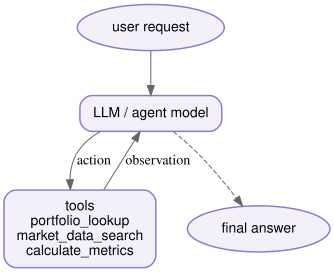

In [23]:
from graphviz import Digraph
from IPython.display import display

def draw_financial_react_diagram():
    """Draw a hand-sketched schematic of the ReAct loop (request → model ⇄ tools → answer)."""
    diagram = Digraph("financial_react", format="png")
    diagram.attr(rankdir="TB", splines="spline", nodesep="0.45", ranksep="0.6")
    diagram.attr(bgcolor="white")

    edge_color = "#666666"
    node_outline = "#8E7CC3"
    node_fill = "#F3F0FA"

    diagram.attr(
        "node",
        style="rounded,filled",
        color=node_outline,
        fillcolor=node_fill,
        fontname="Helvetica",
        fontsize="14",
        penwidth="1.5",
        margin="0.20,0.13",
    )

    diagram.node("request", "user request", shape="oval")
    diagram.node("model", "LLM / agent model", shape="box")
    diagram.node("tools", "tools\nportfolio_lookup\nmarket_data_search\ncalculate_metrics", shape="box")
    diagram.node("result", "final answer", shape="oval")

    with diagram.subgraph() as same_rank:
        same_rank.attr(rank="same")
        same_rank.node("tools")
        same_rank.node("result")

    diagram.edge("request", "model", color=edge_color)
    diagram.edge("model", "tools", label="action", color=edge_color)
    diagram.edge("tools", "model", label="observation", color=edge_color)
    diagram.edge("model", "result", style="dashed", color=edge_color)

    return diagram

display(draw_financial_react_diagram())

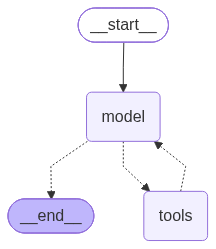

In [24]:
from IPython.display import Image, display
display(Image(agent.get_graph().draw_mermaid_png()))

## 11. Run Agent — Quarterly Client Briefing

The main use case: preparing a comprehensive briefing for a quarterly client meeting. Watch how the agent autonomously queries the database, searches policy PDFs, and pulls live web data.

In [25]:
query1 = """Prepare a quarterly briefing for Client CLT-001 (Rajesh Mehta).
Include: portfolio performance summary with per-holding returns, relevant market conditions
for his sectors, check if his current allocation complies with our investment policies for
his risk profile (Moderate-Aggressive), and provide any recommended rebalancing actions.
Also check for latest news on sectors he is most exposed to."""

print(f"📋 Query: {query1}")
print(f"{'='*80}\n")

# result1 = agent.invoke({"messages": [("user", query1)]})
result1 = agent.invoke(
    {
        "messages": [
            {"role": "user", "content": query1}
        ]
    }
)

print("\n🤖 AGENT RESPONSE:")
print(f"{'─'*80}")
# print(result1["messages"][-1].content)
final_msg = result1["messages"][-1]
print(final_msg.content if hasattr(final_msg, "content") else final_msg)

📋 Query: Prepare a quarterly briefing for Client CLT-001 (Rajesh Mehta).
Include: portfolio performance summary with per-holding returns, relevant market conditions
for his sectors, check if his current allocation complies with our investment policies for
his risk profile (Moderate-Aggressive), and provide any recommended rebalancing actions.
Also check for latest news on sectors he is most exposed to.


🤖 AGENT RESPONSE:
────────────────────────────────────────────────────────────────────────────────
Portfolio briefing — Rajesh Mehta (CLT‑001)
Date: Current quarter review (latest market news checked: last 30 days)

1) Portfolio summary
- Total portfolio value: ₹2,532,500 (≈ ₹25.33 lakh)
- Cost basis: ₹1,894,000 → unrealized gain: ₹638,500 (33.7% YTD/overall)
- Risk profile: Moderate‑Aggressive (Investment horizon 7–10 years) — confirmed from account record.

Holdings (current; market values, unrealized gain, portfolio weight)
- TCS — 150 shares @ ₹4,250 → value ₹637,500; unrealized ga

## 12. Agent Trace — Tool Calls & Reasoning

Let's inspect the full trace to understand the agent's decision-making: which tools it called, in what order, and what it observed.

A full briefing trace

**Figure — A full briefing trace.** A single recorded run shows the agent calling all five tools in sequence to assemble Client CLT-001's quarterly briefing — portfolio → market → compliance → news.

In [ ]:
print("🔍 AGENT TRACE — Full Message History")
print(f"{'='*80}\n")

for step_index, message in enumerate(result1["messages"]):
    message_type = type(message).__name__

    if message_type == "HumanMessage":
        print(f"Step {step_index} | 👤 USER:")
        print(f"   {message.content[:200]}...")

    elif message_type == "AIMessage":
        if hasattr(message, 'tool_calls') and message.tool_calls:
            print(f"\nStep {step_index} | 🧠 AGENT → calls {len(message.tool_calls)} tool(s):")
            for tool_call in message.tool_calls:
                args_str = json.dumps(tool_call['args'], ensure_ascii=False)[:120]
                print(f"   🔧 {tool_call['name']}({args_str})")
        else:
            print(f"\nStep {step_index} | 🤖 FINAL ANSWER ({len(message.content)} chars)")

    elif message_type == "ToolMessage":
        print(f"\nStep {step_index} | 📦 TOOL: {message.name}")
        print(f"   {str(message.content)[:200]}...")

print(f"\n{'='*80}")
tool_messages = [message for message in result1["messages"] if type(message).__name__ == "ToolMessage"]
print(f"Total steps: {len(result1['messages'])} | Tool calls: {len(tool_messages)}")
print(f"Tools used: {[message.name for message in tool_messages]}")

## 13. Run Agent — Cross-Client Comparison with Policy Check

This query requires the agent to query the database for two clients, compare positions, and search policy PDFs for concentration rules.

In [ ]:
def call_agent(query):
    """Run the agent on `query`, print the answer, and report which tools (web/policy) it used."""
    print(f"📋 Query: {query}")
    print(f"{'='*80}\n")

    result = agent.invoke(
        {
            "messages": [
                {"role": "user", "content": query}
            ]
        }
    )

    print("\n🤖 AGENT RESPONSE:")
    print(f"{'─'*80}")

    final_msg = result["messages"][-1]
    print(final_msg.content if hasattr(final_msg, "content") else final_msg)

    tool_calls = [message for message in result["messages"] if type(message).__name__ == "ToolMessage"]
    print(f"\n📊 Tools used: {[message.name for message in tool_calls]}")

    web_calls = [message for message in result["messages"]
                 if type(message).__name__ == "ToolMessage" and message.name == "tavily_search"]
    print(f"\n🌐 Web search called: {len(web_calls)} time(s)")

    # Verify policy_retriever was used
    policy_calls = [message for message in result["messages"]
                    if type(message).__name__ == "ToolMessage" and message.name == "policy_retriever"]
    print(f"\n📚 Policy retriever called: {len(policy_calls)} time(s)")
    for policy_call in policy_calls:
        pdf_refs = re.findall(r'[A-Za-z_]+\.pdf', policy_call.content)
        if pdf_refs:
            print(f"   Referenced PDFs: {', '.join(set(pdf_refs))}")

    return result

In [ ]:
query2 = """Compare the IT sector exposure of Client CLT-001 and Client CLT-002.
Which client is more overweight in IT? Check our sector concentration policy limits
from the policy documents and recommend if either client needs to trim IT positions.
Also look up the latest market outlook for Indian IT sector."""

result2 = call_agent(query2)

## 14. Run Agent — Single-Stock Concentration & Risk Policy Check

This query specifically tests the RAG policy retriever — the agent must search PDF documents for concentration limits and stop-loss rules.

In [ ]:
query3 = """Client CLT-003 (Amit Choudhury) wants to increase his position in Adani Enterprises.
Check his current Adani holding as a percentage of his total portfolio from the database,
then search our policy documents for the single-stock concentration limit and the stop-loss
framework for his risk profile (Aggressive). Advise whether this purchase is permissible."""

result3 = call_agent(query3)

## 15. Run Agent — Live Web Search for Market Intelligence

This query tests Tavily web search — the agent searches for real-time market information not available in our internal data.

In [ ]:
query4 = """Client CLT-005 (Karan Malhotra) has heavy exposure to Telecom and Auto sectors.
Look up his portfolio from the database, then search the web for the latest news on RBI
monetary policy decisions and their potential impact on these sectors.
Summarize the outlook and recommend any portfolio actions."""

result4 = call_agent(query4)

## 16. Agent Performance Summary

Three data backends

**Figure — Three data backends.** The agent draws on SQLite (structured records), FAISS (policy RAG), and Tavily (live web) — each answering a different kind of question.

In [ ]:
all_results = [
    ("Client Briefing (CLT-001)", result1),
    ("IT Sector Comparison", result2),
    ("Concentration Policy Check", result3),
    ("Web Search + Sector Outlook", result4)
]

print("📊 Agent Tool Usage Summary")
print(f"{'='*70}")
print(f"{'Query':<35} {'# Tools':<10} {'Tools Used'}")
print(f"{'─'*70}")

total_calls = 0
tool_frequency = {}

for name, result in all_results:
    tool_messages = [message for message in result["messages"] if type(message).__name__ == "ToolMessage"]
    tool_names = [message.name for message in tool_messages]
    total_calls += len(tool_names)
    for tool_name in tool_names:
        tool_frequency[tool_name] = tool_frequency.get(tool_name, 0) + 1
    print(f"{name:<35} {len(tool_names):<10} {', '.join(tool_names)}")

print(f"{'─'*70}")
print(f"{'TOTAL':<35} {total_calls}")

print(f"\n📈 Tool Frequency:")
for tool_name, count in sorted(tool_frequency.items(), key=lambda pair: -pair[1]):
    print(f"   {tool_name:<25} {count:>2} {'█' * count}")

# Data infrastructure summary
conn = sqlite3.connect(DB_PATH)
print(f"\n🏗️ Data Infrastructure Summary:")
print(f"   SQLite: {DB_PATH} ({os.path.getsize(DB_PATH)/1024:.0f} KB)")
for table in ["clients", "holdings", "market_data"]:
    count = conn.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    print(f"     → {table}: {count} rows")
conn.close()
print(f"   FAISS: {policy_vectorstore.index.ntotal} vectors from {len(pdf_files)} policy PDFs")
print(f"   Web: Tavily API (live search)")

## 17. Conclusion & Next Steps

### What We Built — Portfolio Project Deliverable 🏗️

A **production-grade ReAct agent** for wealth management that:
- Queries a **SQLite database** with 3 normalized tables (clients, holdings, market data)
- Loads **5 real PDF policy documents** through a full RAG pipeline (PyPDFLoader → RecursiveCharacterTextSplitter → OpenAI embeddings → FAISS)
- Searches the **live web** via Tavily API for real-time market intelligence
- Autonomously orchestrates **5 tools** to prepare comprehensive client briefings

### Production Architecture Mapping
| Component | This Lab | Production Equivalent |
|-----------|---------|----------------------|
| Structured data | SQLite | PostgreSQL / Snowflake / Oracle |
| Document store | PDF files on disk | S3 / SharePoint / Document Management System |
| Vector store | FAISS (in-memory) | Pinecone / Weaviate / pgvector |
| Embeddings | text-embedding-3-small | Same, or domain-fine-tuned model |
| Agent LLM | gpt-5-mini | Same, with guardrails and rate limits |
| Web search | Tavily API | Same, or Bloomberg/Reuters enterprise feeds |

### Key Takeaways
1. **Real databases > Python dicts** — SQL gives you joins, filtering, aggregation, and scales to millions of rows
2. **PDF → RAG pipeline** is the production pattern: Load → Split → Embed → Store → Retrieve
3. **Chunk size matters** — 500 chars with 100 overlap balances precision vs. context
4. **RAG as a tool** — the agent decides *when* to search policies, not the developer
5. **The ReAct trace is your debugging superpower** — always inspect tool call sequences in development

### Extension Exercises
- Add a `generate_pdf_report` tool that creates a formatted QPR from the agent's findings
- Implement **conversation memory** with `MemorySaver` for multi-turn client discussions
- Add **human-in-the-loop** approval before executing rebalancing recommendations
- Connect to a real market data API (Yahoo Finance or NSE Bhavcopy) instead of static data
- Deploy as a **FastAPI service** with authentication and rate limiting 🚀